In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("IMT2024011_train_var1.csv")
test  = pd.read_csv("IMT2024011_test_var1.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)
print(train.head())
print("missing values:", train.isna().sum().sum(), test.isna().sum().sum())
print(train.describe().T[["min", "max", "mean", "std"]])

train shape: (1000, 7)
test shape : (1000, 6)
         x1        x2        x3        x4        x5        x6         y
0 -1.000000  0.429176  0.149195 -0.949468  1.000000  1.000000  7.065800
1 -0.459175 -0.270491 -0.274152 -0.252233 -0.600951 -1.000000  1.984589
2 -1.000000 -1.000000 -0.827189  0.069369  0.002361  0.922246  0.094805
3  1.000000 -0.008912  1.000000  1.000000  1.000000  0.142745 -6.016547
4 -1.000000 -1.000000 -0.600127 -0.412395  1.000000 -0.627946  0.978208
missing values: 0 0
         min        max      mean       std
x1 -1.000000   1.000000 -0.011937  0.712185
x2 -1.000000   1.000000 -0.027546  0.697996
x3 -1.000000   1.000000 -0.039620  0.724730
x4 -1.000000   1.000000 -0.002957  0.704261
x5 -1.000000   1.000000 -0.034971  0.723304
x6 -1.000000   1.000000 -0.005689  0.718421
y  -8.993296  12.307388  0.919432  3.144042


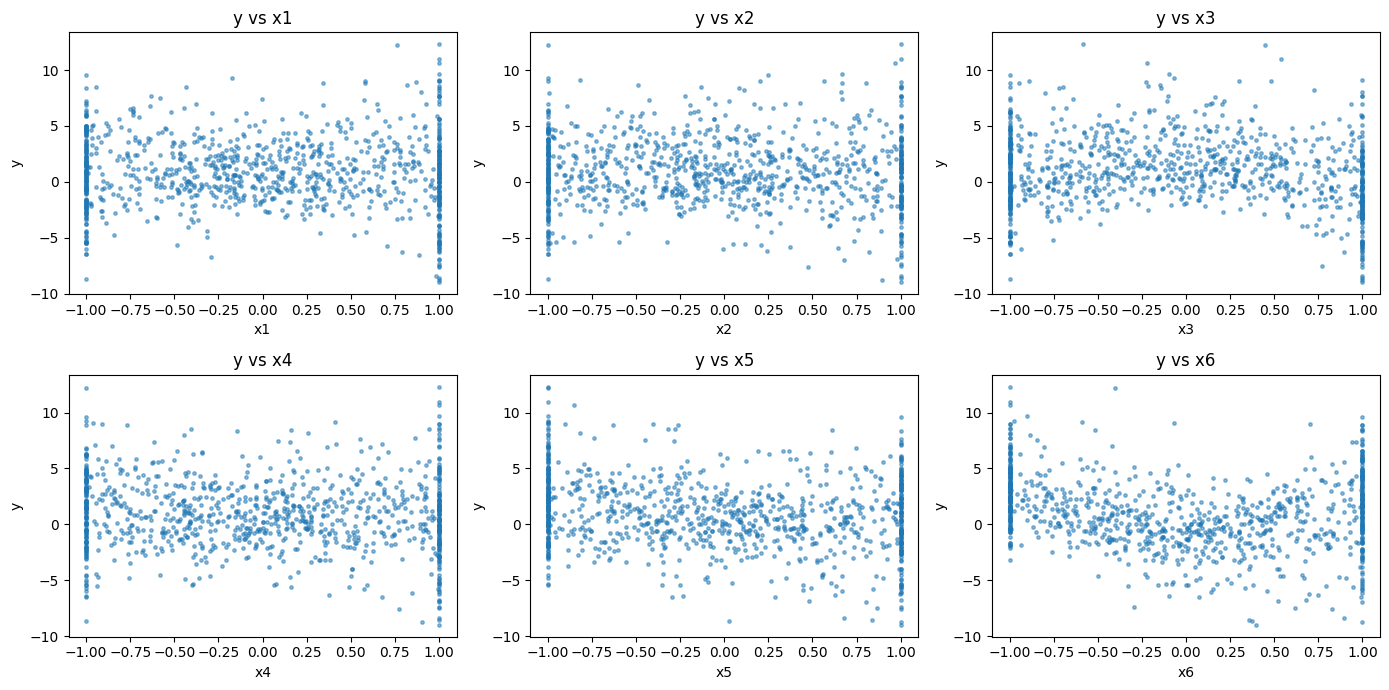

In [ ]:
features = ["x1", "x2", "x3", "x4", "x5", "x6"]

# --- y vs each variable ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, f in zip(axes.ravel(), features):
    ax.scatter(train[f], train["y"], s=6, alpha=0.5)
    ax.set_xlabel(f)
    ax.set_ylabel("y")
    ax.set_title(f"y vs {f}")
plt.tight_layout()
plt.show()

X = train[features].values.astype(np.float64)
y = train["y"].values.astype(np.float64)
X_test = test[features].values.astype(np.float64)

      x1    x2    x3    x4    x5    x6     y
x1  1.00  0.50  0.41  0.49 -0.00  0.12 -0.02
x2  0.50  1.00  0.43  0.45 -0.00  0.04 -0.03
x3  0.41  0.43  1.00  0.43 -0.02  0.08 -0.15
x4  0.49  0.45  0.43  1.00  0.01  0.03 -0.09
x5 -0.00 -0.00 -0.02  0.01  1.00  0.45 -0.21
x6  0.12  0.04  0.08  0.03  0.45  1.00 -0.20
y  -0.02 -0.03 -0.15 -0.09 -0.21 -0.20  1.00


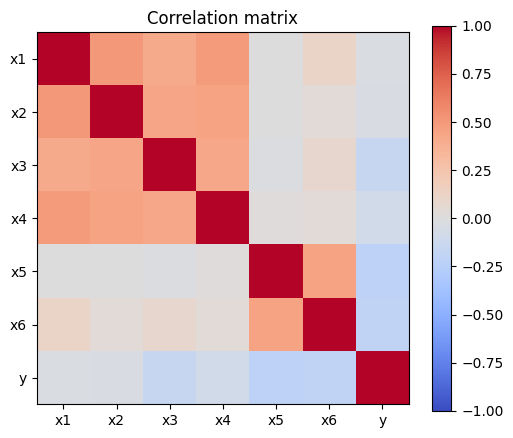

x1*x5   -0.445
x6^2     0.383
x2*x3   -0.353
x3^2    -0.290
x3*x6   -0.247
x1*x6   -0.240
x5      -0.213
x3*x5   -0.211
x1*x3   -0.209
x3*x4   -0.206
x6      -0.197
x4*x5   -0.185
x4*x6   -0.165
x5*x6    0.164
x3      -0.151
dtype: float64


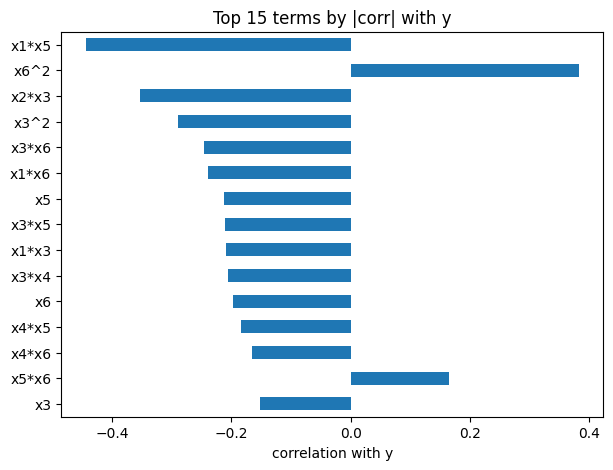

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from itertools import combinations

# (a) plain correlation matrix incl. y
corr = train[features + ["y"]].corr()
print(corr.round(2))

plt.figure(figsize=(6, 5))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(7), corr.columns); plt.yticks(range(7), corr.columns)
plt.title("Correlation matrix"); plt.show()

# (b) correlation of y with engineered terms: x_i, x_i^2, x_i*x_j
terms = {}
for f in features:
    terms[f] = train[f]
    terms[f + "^2"] = train[f] ** 2
for a, b in combinations(features, 2):
    terms[a + "*" + b] = train[a] * train[b]

r = pd.Series({k: np.corrcoef(v, train["y"])[0, 1] for k, v in terms.items()})
top = r.reindex(r.abs().sort_values(ascending=False).index).head(15)
print(top.round(3))

top[::-1].plot.barh(figsize=(7, 5))
plt.xlabel("correlation with y"); plt.title("Top 15 terms by |corr| with y")
plt.show()

In [ ]:
import os, itertools, time
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

# ---------- device & dtype ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# float32 is much faster on GPU and accurate enough here; use float64 if you need bit-identical results
DTYPE = torch.float32 if DEVICE.type == "cuda" else torch.float64
torch.set_default_dtype(DTYPE)
print(f"device: {DEVICE} | dtype: {DTYPE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

os.makedirs("output", exist_ok=True)

# numpy copies kept for diagnostics; tensors live on DEVICE
X_np = train[features].values
y_np = train["y"].values
X_test_np = test[features].values
X = torch.as_tensor(X_np, dtype=DTYPE, device=DEVICE)
y = torch.as_tensor(y_np, dtype=DTYPE, device=DEVICE)
X_test = torch.as_tensor(X_test_np, dtype=DTYPE, device=DEVICE)

def poly_features(A, deg):
    cols = [A[:, list(c)].prod(dim=1)
            for d in range(1, deg + 1)
            for c in itertools.combinations_with_replacement(range(A.shape[1]), d)]
    return torch.stack(cols, dim=1)

def soft(v, t):
    return torch.sign(v) * torch.clamp(v.abs() - t, min=0)

def rmse(A, t, w, b):
    return torch.sqrt(((A @ w + b - t) ** 2).mean())

# argmin ||y - Xb||^2 + lam2*||b||^2 + lam1*||b||_1   (bias not penalized)
# Analytical gradients (GPU-friendly) — same math as the old autograd version
def fit_enet(Xt, yt, lam1, lam2, sigma, iters, Xv=None, yv=None, log_every=1):
    L = 2 * (sigma ** 2 + lam2)
    p = Xt.shape[1]
    w = torch.zeros(p, dtype=Xt.dtype, device=Xt.device)
    b = torch.zeros((), dtype=Xt.dtype, device=Xt.device)
    zw, zb, t = w.clone(), b.clone(), 1.0
    n_log = max(iters // log_every, 1)
    tr_buf = torch.empty(n_log, dtype=Xt.dtype, device=Xt.device)
    va_buf = torch.empty(n_log, dtype=Xt.dtype, device=Xt.device) if Xv is not None else None
    log_i = 0
    XtT = Xt.T.contiguous()   # (p, n) reused every iteration
    for i in range(iters):
        r = Xt @ zw + zb - yt
        gw = 2 * (XtT @ r) + (2 * lam2) * zw
        gb = 2 * r.sum()
        w_new = soft(zw - gw / L, lam1 / L)
        b_new = zb - gb / L
        t_new = (1 + (1 + 4 * t * t) ** 0.5) / 2
        mom = (t - 1) / t_new
        zw = w_new + mom * (w_new - w)
        zb = b_new + mom * (b_new - b)
        w, b, t = w_new, b_new, t_new
        if (i + 1) % log_every == 0:
            tr_buf[log_i] = rmse(Xt, yt, w, b)
            if Xv is not None:
                va_buf[log_i] = rmse(Xv, yv, w, b)
            log_i += 1
    if Xv is None:
        return w, b, tr_buf
    return w, b, tr_buf, va_buf

def run_degree(DEG, lam1_grid, lam2_grid, K=10, iters=800, final_iters=3000,
               log_every=1, seed=0, out_dir="output", show=False):
    t0 = time.time()
    folder = os.path.join(out_dir, f"deg{DEG}"); os.makedirs(folder, exist_ok=True)
    Phi = poly_features(X, DEG)
    Phi_test = poly_features(X_test, DEG)
    Y = y
    n, p = Phi.shape
    folds = torch.randperm(n, generator=torch.Generator(device="cpu").manual_seed(seed)).chunk(K)
    n_log = iters // log_every
    curves = torch.zeros(len(lam1_grid), len(lam2_grid), K, 2, n_log, dtype=DTYPE, device=DEVICE)

    for k in range(K):
        va = folds[k].to(DEVICE)
        tr = torch.cat([folds[j] for j in range(K) if j != k]).to(DEVICE)
        Xt, yt, Xv, yv = Phi[tr], Y[tr], Phi[va], Y[va]
        ones = torch.ones(len(tr), 1, dtype=DTYPE, device=DEVICE)
        sigma = torch.linalg.matrix_norm(torch.cat([Xt, ones], 1), 2)
        for i, l1 in enumerate(lam1_grid):
            for j, l2 in enumerate(lam2_grid):
                _, _, c_tr, c_va = fit_enet(Xt, yt, l1, l2, sigma, iters, Xv, yv, log_every)
                curves[i, j, k, 0], curves[i, j, k, 1] = c_tr, c_va
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        print(f"deg {DEG}: fold {k+1}/{K} done ({(time.time()-t0)/60:.1f} min)")

    final = curves[..., 1, -1]                              # val RMSE at last logged iter
    cv_rmse = final.mean(dim=2)
    bi, bj = divmod(int(cv_rmse.argmin().item()), len(lam2_grid))
    cv_se = (final[bi, bj].std() / (K ** 0.5)).item()

    # ---- plot 1: train/val curves (CPU for matplotlib) ----
    curves_cpu = curves.detach().cpu()
    cv_rmse_cpu = cv_rmse.detach().cpu()
    fig, axes = plt.subplots(len(lam1_grid), len(lam2_grid), figsize=(4 * len(lam2_grid), 3 * len(lam1_grid)),
                             sharex=True, sharey=True, squeeze=False)
    it = torch.arange(1, n_log + 1) * log_every
    for i in range(len(lam1_grid)):
        for j in range(len(lam2_grid)):
            ax = axes[i, j]
            for idx, (name, col) in enumerate([("train", "tab:blue"), ("val", "tab:orange")]):
                m = curves_cpu[i, j, :, idx].mean(0).numpy()
                s = curves_cpu[i, j, :, idx].std(0).numpy()
                ax.plot(it.numpy(), m, color=col, label=name)
                ax.fill_between(it.numpy(), m - s, m + s, color=col, alpha=0.2)
            ax.set_title(f"λ1={lam1_grid[i]}, λ2={lam2_grid[j]}", fontsize=9); ax.set_ylim(0, 4)
            if (i, j) == (bi, bj):
                for sp in ax.spines.values(): sp.set_color("red"); sp.set_linewidth(3)
    axes[0, 0].legend(); fig.supxlabel("iteration"); fig.supylabel(f"RMSE (mean ± std, {K} folds)")
    fig.suptitle(f"Degree {DEG}: train vs val curves"); plt.tight_layout()
    fig.savefig(os.path.join(folder, "train_val_curves.png"), dpi=110)
    plt.show() if show else plt.close(fig)

    # ---- plot 2: CV heatmap ----
    fig = plt.figure(figsize=(7, 5))
    plt.imshow(cv_rmse_cpu.numpy(), cmap="viridis_r", aspect="auto"); plt.colorbar(label=f"{K}-fold CV RMSE")
    plt.xticks(range(len(lam2_grid)), lam2_grid); plt.yticks(range(len(lam1_grid)), lam1_grid)
    plt.xlabel("λ2 (L2)"); plt.ylabel("λ1 (L1)"); plt.scatter(bj, bi, c="red", marker="*", s=200)
    plt.title(f"Degree {DEG}: CV RMSE grid"); plt.tight_layout()
    fig.savefig(os.path.join(folder, "cv_heatmap.png"), dpi=110)
    plt.show() if show else plt.close(fig)

    # ---- final refit on all data, predict test ----
    ones_all = torch.ones(n, 1, dtype=DTYPE, device=DEVICE)
    sigma = torch.linalg.matrix_norm(torch.cat([Phi, ones_all], 1), 2)
    w, b, _ = fit_enet(Phi, Y, lam1_grid[bi], lam2_grid[bj], sigma, final_iters)
    w_cpu, b_cpu = w.detach().cpu(), b.detach().cpu()
    test_pred = (Phi_test @ w + b).detach().cpu().numpy()
    pd.DataFrame({"y_pred": test_pred}).to_csv(os.path.join(folder, "test_predictions.csv"), index=False)
    torch.save({
        "curves": curves_cpu, "cv_rmse": cv_rmse_cpu,
        "w": w_cpu, "b": b_cpu,
    }, os.path.join(folder, "results.pt"))

    res = dict(
        deg=DEG, n_features=p, lam1=lam1_grid[bi], lam2=lam2_grid[bj],
        cv_rmse=cv_rmse[bi, bj].item(), cv_se=cv_se,
        train_rmse=rmse(Phi, Y, w, b).item(),
        nonzero=int((w.abs() > 1e-6).sum().item()),
    )
    print(f"deg {DEG}: best λ1={res['lam1']}, λ2={res['lam2']}, CV RMSE={res['cv_rmse']:.4f} ± {res['cv_se']:.4f}, "
          f"nonzero {res['nonzero']}/{p}  [{(time.time()-t0)/60:.1f} min]")
    return res


device: cuda | dtype: torch.float32
GPU: Tesla T4


deg 1: fold 1/10 done (0.8 min)
deg 1: fold 2/10 done (1.6 min)
deg 1: fold 3/10 done (2.4 min)
deg 1: fold 4/10 done (3.2 min)
deg 1: fold 5/10 done (3.9 min)
deg 1: fold 6/10 done (4.7 min)
deg 1: fold 7/10 done (5.4 min)
deg 1: fold 8/10 done (6.2 min)
deg 1: fold 9/10 done (7.0 min)
deg 1: fold 10/10 done (7.7 min)
deg 1: best λ1=0, λ2=30, CV RMSE=3.0185 ± 0.0643, nonzero 6/6  [8.1 min]
deg 2: fold 1/10 done (0.8 min)
deg 2: fold 2/10 done (1.5 min)
deg 2: fold 3/10 done (2.3 min)
deg 2: fold 4/10 done (3.1 min)
deg 2: fold 5/10 done (3.8 min)
deg 2: fold 6/10 done (4.6 min)
deg 2: fold 7/10 done (5.4 min)
deg 2: fold 8/10 done (6.1 min)
deg 2: fold 9/10 done (6.9 min)
deg 2: fold 10/10 done (7.7 min)
deg 2: best λ1=10, λ2=0, CV RMSE=1.7765 ± 0.0445, nonzero 25/27  [8.1 min]
deg 3: fold 1/10 done (0.8 min)
deg 3: fold 2/10 done (1.5 min)
deg 3: fold 3/10 done (2.3 min)
deg 3: fold 4/10 done (3.1 min)
deg 3: fold 5/10 done (3.9 min)
deg 3: fold 6/10 done (4.7 min)
deg 3: fold 7/10 d

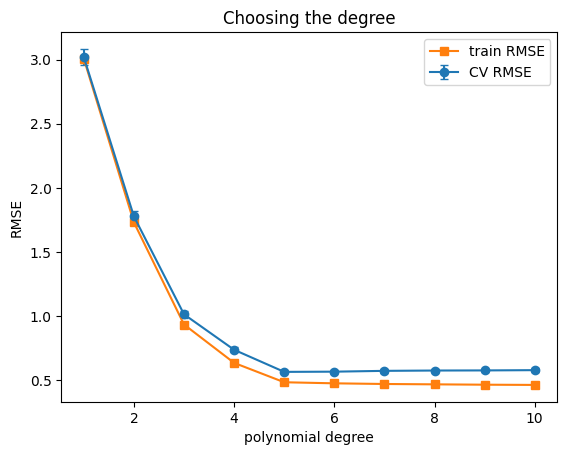

In [ ]:
lam1_grid = [0, 0.5, 1, 2, 3, 4, 6, 10, 15, 30]
lam2_grid = [0, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

summary = [run_degree(d, lam1_grid, lam2_grid, K=10) for d in range(1, 11)] # Max degree we can use is 10
df = pd.DataFrame(summary); print(df)
df.to_csv("output/degree_summary.csv", index=False)

# degree-comparison plot
plt.errorbar(df.deg, df.cv_rmse, yerr=df.cv_se, marker="o", capsize=3, label="CV RMSE")
plt.plot(df.deg, df.train_rmse, marker="s", label="train RMSE")
plt.xlabel("polynomial degree"); plt.ylabel("RMSE"); plt.legend(); plt.title("Choosing the degree")
plt.savefig("output/degree_comparison.png", dpi=110); plt.show()

In [ ]:
! zip outputs.zip /content/output/* -r

  adding: content/output/deg1/ (stored 0%)
  adding: content/output/deg1/cv_heatmap.png (deflated 17%)
  adding: content/output/deg1/train_val_curves.png (deflated 33%)
  adding: content/output/deg1/test_predictions.csv (deflated 53%)
  adding: content/output/deg1/results.pt (deflated 97%)
  adding: content/output/deg10/ (stored 0%)
  adding: content/output/deg10/cv_heatmap.png (deflated 15%)
  adding: content/output/deg10/train_val_curves.png (deflated 8%)
  adding: content/output/deg10/test_predictions.csv (deflated 51%)
  adding: content/output/deg10/results.pt (deflated 23%)
  adding: content/output/deg2/ (stored 0%)
  adding: content/output/deg2/cv_heatmap.png (deflated 15%)
  adding: content/output/deg2/train_val_curves.png (deflated 17%)
  adding: content/output/deg2/test_predictions.csv (deflated 51%)
  adding: content/output/deg2/results.pt (deflated 71%)
  adding: content/output/deg3/ (stored 0%)
  adding: content/output/deg3/cv_heatmap.png (deflated 14%)
  adding: content/ou

### From above it is clear that we have best output when 4<λ1<10 and λ2=0 for all values of degrees. So now we will fine tune our λ1 in between these values only with the best degree, which is 5 only.

In [ ]:
res = run_degree(5, lam1_grid=[4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8.5, 10], lam2_grid=[0], K=10, out_dir="output_final")

deg 5: fold 1/10 done (0.1 min)
deg 5: fold 2/10 done (0.2 min)
deg 5: fold 3/10 done (0.2 min)
deg 5: fold 4/10 done (0.3 min)
deg 5: fold 5/10 done (0.4 min)
deg 5: fold 6/10 done (0.5 min)
deg 5: fold 7/10 done (0.6 min)
deg 5: fold 8/10 done (0.6 min)
deg 5: fold 9/10 done (0.7 min)
deg 5: fold 10/10 done (0.8 min)
deg 5: best λ1=5.5, λ2=0, CV RMSE=0.5644 ± 0.0123, nonzero 126/461  [0.8 min]


out-of-fold RMSE: 0.5656 | R²: 0.9676


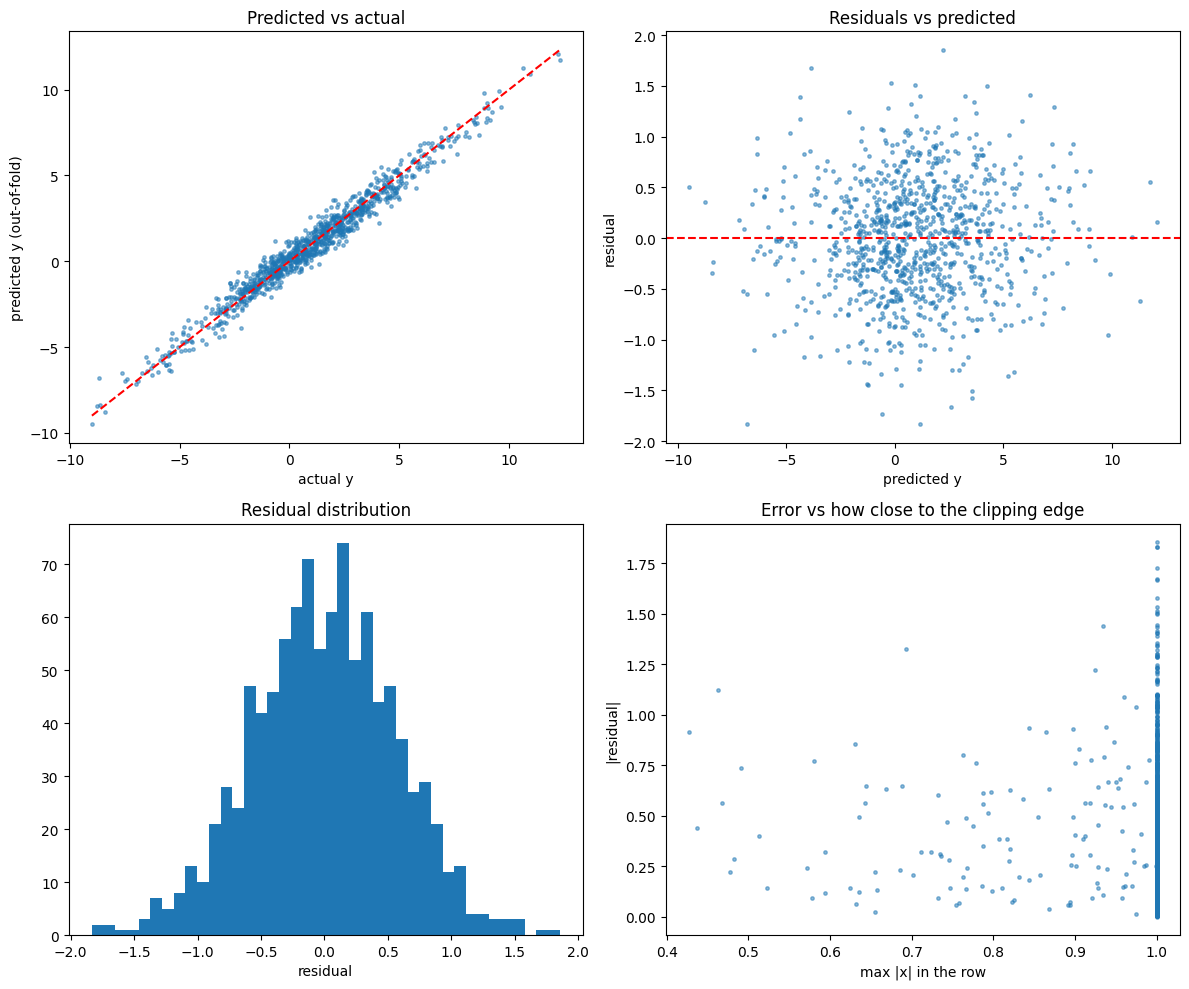

x1 x5            -2.666
x2 x2 x2 x3      -2.391
x2 x4 x6         -1.892
x3 x6            -1.669
x1 x3 x3 x6 x6   -1.544
x2 x2 x4 x4 x5   -1.512
x3 x3 x3 x6 x6   -1.508
x4 x4 x5 x5       1.490
x6 x6             1.482
x1 x1 x3 x3 x5   -1.372
x3 x3 x4 x4      -1.307
x6 x6 x6 x6       1.266
x1 x3 x6 x6       1.153
x1 x2 x2 x4 x4    1.025
x3 x3 x5 x5      -1.020
dtype: float32
test pred range: -10.13 14.95 | train y range: -8.989999771118164 12.3100004196167


In [ ]:
import itertools, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
DEG, LAM1, K, ITERS = 5, 5.5, 10, 800

Phi = poly_features(X, DEG)
Phi_test = poly_features(X_test, DEG)
Y = y
n = len(Phi)

# ---- 1. out-of-fold predictions: each row is predicted by a model that never saw it ----
folds = torch.randperm(n, generator=torch.Generator(device="cpu").manual_seed(0)).chunk(K)
oof = torch.zeros(n, dtype=DTYPE, device=DEVICE)
for k in range(K):
    va = folds[k].to(DEVICE)
    tr = torch.cat([folds[j] for j in range(K) if j != k]).to(DEVICE)
    ones = torch.ones(len(tr), 1, dtype=DTYPE, device=DEVICE)
    sigma = torch.linalg.matrix_norm(torch.cat([Phi[tr], ones], 1), 2)
    w_k, b_k, _ = fit_enet(Phi[tr], Y[tr], LAM1, 0.0, sigma, ITERS)
    oof[va] = Phi[va] @ w_k + b_k
res = (Y - oof).detach().cpu().numpy()
y_cpu = y.detach().cpu().numpy()
print(f"out-of-fold RMSE: {np.sqrt((res**2).mean()):.4f} | R²: {1 - (res**2).sum() / ((y_cpu - y_cpu.mean())**2).sum():.4f}")

# ---- 2. final model (fit on all training data) ----
r = torch.load("output_final/deg5/results.pt", map_location="cpu", weights_only=False)
w, b = r["w"], r["b"]
w_d = w.to(device=DEVICE, dtype=DTYPE)
b_d = b.to(device=DEVICE, dtype=DTYPE)
fit_tr = (Phi @ w_d + b_d).detach().cpu().numpy()
test_pred = (Phi_test @ w_d + b_d).detach().cpu().numpy()
oof_np = oof.detach().cpu().numpy()

# ---- 3. diagnostic plots ----
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0,0].scatter(y_cpu, oof_np, s=6, alpha=0.5); lim = [y_cpu.min(), y_cpu.max()]
ax[0,0].plot(lim, lim, "r--"); ax[0,0].set(xlabel="actual y", ylabel="predicted y (out-of-fold)", title="Predicted vs actual")
ax[0,1].scatter(oof_np, res, s=6, alpha=0.5); ax[0,1].axhline(0, color="r", ls="--")
ax[0,1].set(xlabel="predicted y", ylabel="residual", title="Residuals vs predicted")
ax[1,0].hist(res, bins=40); ax[1,0].set(xlabel="residual", title="Residual distribution")
ax[1,1].scatter(np.abs(X_np).max(1), np.abs(res), s=6, alpha=0.5)
ax[1,1].set(xlabel="max |x| in the row", ylabel="|residual|", title="Error vs how close to the clipping edge")
plt.tight_layout(); plt.savefig("output_final/diagnostics.png", dpi=110); plt.show()

# ---- 4. which terms did the model keep? ----
names = [" ".join(f"x{i+1}" for i in c)
         for d in range(1, DEG + 1) for c in itertools.combinations_with_replacement(range(6), d)]
w_np = w.numpy() if hasattr(w, "numpy") else np.asarray(w)
top = pd.Series(w_np, index=names); top = top[top != 0]
top = top.reindex(top.abs().sort_values(ascending=False).index)
print(top.head(15).round(3))

# ---- 5. save test predictions ----
pd.DataFrame({"y_pred": test_pred}).to_csv("output_final/test_predictions_final.csv", index=False)
print("test pred range:", test_pred.min().round(2), test_pred.max().round(2),
      "| train y range:", float(y_cpu.min().round(2)), float(y_cpu.max().round(2)))


In [ ]:
! zip outputs_final.zip /content/output_final/* -r

  adding: content/output_final/deg5/ (stored 0%)
  adding: content/output_final/deg5/cv_heatmap.png (deflated 17%)
  adding: content/output_final/deg5/train_val_curves.png (deflated 16%)
  adding: content/output_final/deg5/test_predictions.csv (deflated 51%)
  adding: content/output_final/deg5/results.pt (deflated 30%)
  adding: content/output_final/diagnostics.png (deflated 8%)
  adding: content/output_final/test_predictions_final.csv (deflated 51%)
